# Final schedule analysis notebook

Ce notebook :

- lit **`data.dzn`** (données MiniZinc) ;
- lit **`solution.json`** (solution MiniZinc exportée en JSON, via `--output-mode json` ou un `output` JSON) ;
- reconstruit le tenseur `x_ijq` ;
- calcule et visualise toutes les métriques d'horaire que tu voulais, **une métrique par cellule** :
  - distribution du nombre d'employés au cours de la journée (avec semaine / weekend + heatmap jour × heure) ;
  - distribution des patients et des appels raccrochés ;
  - heures totales, heures supplémentaires, variance d'heures (par type d'employé) ;
  - nombre de jours consécutifs travaillés ;
  - changements brusques de quarts ;
  - nuits travaillées ;
  - répartition jour / soir / nuit / weekend ;
  - nombre de personnes par quart et par type ;
  - timeline horizontale (type Gantt) par employé.


In [148]:
import os
scenario_dir='scenario_default'
os.makedirs(scenario_dir,exist_ok=True)


## 1. Imports et fonctions utilitaires

In [149]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def slot_to_time_15(h):
    """Convertit un identifiant de tranche 15min (1..96) en 'HH:MM'."""
    total_minutes = (h - 1) * 15
    hh = total_minutes // 60
    mm = total_minutes % 60
    return f"{hh:02d}:{mm:02d}"

## 2. Lecture de `data.dzn` et reconstruction des paramètres

In [150]:
def parse_range(expr):
    """Parse '1..11' into python list [1,2,...,11]."""
    a, b = map(int, expr.split(".."))
    return list(range(a, b+1))

def parse_int_list(expr):
    """Parse '[1,2,3]' into [1,2,3]."""
    numbers = re.findall(r"-?\d+\.?\d*", expr)
    return [float(x) if "." in x else int(x) for x in numbers]

def load_data_from_dzn(path="data.dzn"):
    txt = open(path).read()
    data = {}

    # --- 1. Sets IR, IP, IE ---
    for key in ["IR","IP","IE"]:
        m = re.search(rf"{key}\s*=\s*([0-9]+\.\.[0-9]+)", txt)
        if not m:
            raise ValueError(f"Missing set {key} in dzn file")
        data[key] = parse_range(m.group(1))

    # Employees I
    data["I"] = data["IR"] + data["IP"] + data["IE"]

    # --- 2. IN = union of ranges ---
    m = re.search(r"IN\s*=\s*(.*?)\s*;", txt)
    if m:
        expr = m.group(1)
        parts = re.findall(r"(\d+\.\.\d+)", expr)
        IN = []
        for p in parts:
            IN += parse_range(p)
        data["IN"] = IN
    else:
        raise ValueError("Missing IN")

    # --- 3. horizon, J, W ---
    m = re.search(r"horizon\s*=\s*(\d+)", txt)
    data["horizon"] = int(m.group(1))

    data["J"] = list(range(1, data["horizon"]+1))
    data["W"] = list(range(1, data["horizon"]//7 + 1))

    # --- 4. JL, JW ---
    data["JL"] = [j for j in data["J"] if j % 7 == 1]
    data["JW"] = [j for j in data["J"] if (j % 7 == 0 or j % 7 == 6)]

    # --- 5. H ---
    m = re.search(r"H\s*=\s*([0-9]+\.\.[0-9]+)", txt)
    data["H"] = parse_range(m.group(1))

    # --- 6. debut_int, duree_int ---
    def extract_array(name):
        m = re.search(rf"{name}\s*=\s*\[(.*?)\];", txt, re.S)
        if not m:
            raise ValueError(f"Missing array {name}")
        return parse_int_list(m.group(1))

    data["debut_int"] = extract_array("debut_int")
    data["duree_int"] = extract_array("duree_int")

    # fin_int recomputed
    data["fin_int"] = [
        data["debut_int"][i] + data["duree_int"][i]
        for i in range(len(data["debut_int"]))
    ]

    # --- 7. Enumeration Q ---
    data["Q"] = ["q0_8","q7_8","q8_8","q11_5_8","q12_8","q14_8","q16_8","q8_12"]

    # --- 8/9. plages_quarts, plages_pause_60, plages_pause_15 and a_hq (with pauses) ---
    def parse_plage_blocks(name, Q):
        m = re.search(rf"{name}\s*=\s*\[(.*?)\];", txt, re.S)
        if not m:
            raise ValueError(f"Missing {name}")
        content = m.group(1).strip()

        # split by top-level commas (ignore commas inside [] or ())
        parts = []
        buf = []
        depth_sq = 0
        depth_par = 0
        for ch in content:
            if ch == "[":
                depth_sq += 1
            elif ch == "]":
                depth_sq = max(0, depth_sq - 1)
            elif ch == "(":
                depth_par += 1
            elif ch == ")":
                depth_par = max(0, depth_par - 1)

            if ch == "," and depth_sq == 0 and depth_par == 0:
                part = "".join(buf).strip()
                if part != "":
                    parts.append(part)
                buf = []
            else:
                buf.append(ch)
        last = "".join(buf).strip()
        if last != "":
            parts.append(last)

        blocks = []
        for p in parts:
            p = p.strip()
            if p == "":
                blocks.append([])
                continue

            # handle union(...) constructs: collect all ranges inside and merge them
            union_matches = re.findall(r"union\s*\((.*?)\)", p, re.S)
            if union_matches:
                vals = []
                for um in union_matches:
                    # split inner args by top-level commas and parse ranges/lists
                    inner_buf = []
                    in_sq = 0
                    in_par = 0
                    args = []
                    for ch in um:
                        if ch == "[":
                            in_sq += 1
                        elif ch == "]":
                            in_sq = max(0, in_sq - 1)
                        elif ch == "(":
                            in_par += 1
                        elif ch == ")":
                            in_par = max(0, in_par - 1)

                        if ch == "," and in_sq == 0 and in_par == 0:
                            arg = "".join(inner_buf).strip()
                            if arg:
                                args.append(arg)
                            inner_buf = []
                        else:
                            inner_buf.append(ch)
                    last_arg = "".join(inner_buf).strip()
                    if last_arg:
                        args.append(last_arg)

                    for arg in args:
                        # find all ranges inside each arg
                        ranges = re.findall(r"(\d+\.\.\d+)", arg)
                        for r in ranges:
                            vals += parse_range(r)
                        # also allow standalone lists like [1,5,7]
                        if not ranges:
                            nums = re.findall(r"-?\d+\.?\d*", arg)
                            if nums:
                                vals += [int(x) if "." not in x else int(float(x)) for x in nums]
                # unique & sorted
                blocks.append(sorted(set(vals)))
                continue

            # otherwise, try to extract any bracketed subblocks first
            inner_brackets = re.findall(r"\[(.*?)\]", p, re.S)
            if inner_brackets:
                # if the part is itself a list of blocks like [1..3, 5..6]
                if len(inner_brackets) == 1 and re.search(r"\d+\.\.\d+", inner_brackets[0]):
                    ranges = re.findall(r"(\d+\.\.\d+)", inner_brackets[0])
                    vals = []
                    for r in ranges:
                        vals += parse_range(r)
                    blocks.append(vals)
                else:
                    # multiple inner bracketed pieces -> merge all ranges found
                    vals = []
                    for sb in inner_brackets:
                        ranges = re.findall(r"(\d+\.\.\d+)", sb)
                        for r in ranges:
                            vals += parse_range(r)
                        if not ranges:
                            # maybe explicit numbers inside
                            nums = re.findall(r"-?\d+\.?\d*", sb)
                            if nums:
                                vals += [int(x) if "." not in x else int(float(x)) for x in nums]
                    blocks.append(sorted(set(vals)))
                continue

            # fallback: find ranges or numbers in the part
            ranges = re.findall(r"(\d+\.\.\d+)", p)
            if ranges:
                vals = []
                for r in ranges:
                    vals += parse_range(r)
                blocks.append(vals)
                continue

            nums = re.findall(r"-?\d+\.?\d*", p)
            if nums:
                blocks.append([int(x) if "." not in x else int(float(x)) for x in nums])
            else:
                # empty or unrecognized -> empty block
                blocks.append([])

        if len(blocks) != len(Q):
            raise ValueError(f"{name} parsed into {len(blocks)} blocks but Q has length {len(Q)}")
        return blocks

    Q = data["Q"]
    H = data["H"]

    data["plages_quarts"] = parse_plage_blocks("plages_quarts", Q)
    data["plages_pause_60"] = parse_plage_blocks("plages_pause_60", Q)
    data["plages_pause_15"] = parse_plage_blocks("plages_pause_15", Q)

    # build a_hq: 0.0 if not in plage_quarts, 0.5 if in pause_60, 0.75 if in pause_15, else 1.0
    a_hq = np.zeros((len(H), len(Q)), dtype=float)
    for q_idx, q in enumerate(Q):
        plages_q = set(data["plages_quarts"][q_idx])
        pause60_q = set(data["plages_pause_60"][q_idx])
        pause15_q = set(data["plages_pause_15"][q_idx])
        for h in H:
            if h not in plages_q:
                a_hq[h-1, q_idx] = 0.0
            elif h in pause60_q:
                a_hq[h-1, q_idx] = 0.5
            elif h in pause15_q:
                a_hq[h-1, q_idx] = 0.75
            else:
                a_hq[h-1, q_idx] = 1.0
    data["a_hq"] = a_hq
    print(f"a_hq for first Q ({Q[0]}):", a_hq[:,0])

    # --- 10. n_jh ---
    data["n_h_sem"] = np.array(extract_array("n_h_sem"))
    data["n_h_fds"] = np.array(extract_array("n_h_fds"))
    n_jh = []
    for j in data["J"]:
        if j % 7 == 0 or j % 7 == 6:
            n_jh.append(data["n_h_fds"])
        else:
            n_jh.append(data["n_h_sem"])
    data["n_jh"] = np.array(n_jh)

    # --- 11. T_max, c_barre ---
    IR = data["IR"]
    IP = data["IP"]
    IE = data["IE"]

    data["T_max"] = np.array([80.0]*len(IR) + [80.0]*len(IP) + [40.0]*len(IE))
    data["c_barre"] = np.array([24]*len(IR) + [20]*len(IP) + [10]*len(IE))

    # --- 12. Congés C[i] ---
    C = []
    for i in IR:
        if i == 4:
            C.append([1])
        elif i == 7:
            C.append([5])
        else:
            C.append([])
    data["C"] = C

    # --- 13. QN / QJ / QS ---
    data["QN"] = ["q0_8"]
    data["QJ"] = ["q7_8","q8_8","q11_5_8","q12_8","q14_8","q8_12"]
    data["QS"] = ["q16_8","q8_12"]

    # --- 14. patience et lmd ---
    m = re.search(r"\bpatience\s*=\s*(\d+)\s*;", txt)
    data["patience"] = int(m.group(1))

    m = re.search(r"\blmd\s*=\s*(\d+)\s*;", txt)
    data["lmd"] = int(m.group(1))

    # =====================================================
    # 15. POIDS DE L’OBJECTIF
    # =====================================================
    def parse_weight(name):
        m = re.search(rf"{name}\s*=\s*(\d+)\s*;", txt)
        if m:
            return int(m.group(1))
        else:
            raise ValueError(f"Poids manquant dans le .dzn : {name}")

    data["w_preferences"]          = parse_weight("w_preferences")
    data["w_equilibre_jour_soir"]  = parse_weight("w_equilibre_jour_soir")
    data["w_couverture"]           = parse_weight("w_couverture")
    data["w_heures_tot"]           = parse_weight("w_heures_tot")

    return data


# Test
data = load_data_from_dzn("data.dzn")
print("Chargé ✔")
print("Poids =", data["w_preferences"], data["w_equilibre_jour_soir"],
      data["w_couverture"], data["w_heures_tot"])
print("Patience =", data["patience"])
print("lmd =", data["lmd"])


a_hq for first Q (q0_8): [1.   1.   1.   1.   1.   1.   0.75 0.75 0.75 0.75 1.   1.   0.5  0.5
 0.5  0.5  0.5  0.5  0.5  0.5  1.   1.   0.75 0.75 0.75 0.75 1.   1.
 1.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
Chargé ✔
Poids = 1 0 200 20
Patience = 7
lmd = 15


## 3. Lecture de `solution.json` et reconstruction de `x_tensor`

In [151]:
# ============================
# Chargement solution JSON + Vérification
# ============================

def load_solution(path="solution.json"):
    """Charge un JSON MiniZinc et retourne (sol, x_tensor)."""
    with open(path, "r") as f:
        sol_raw = json.load(f)

    # Deux formats possibles :
    if isinstance(sol_raw, dict) and "solutions" in sol_raw:
        sol = sol_raw["solutions"][-1]
    else:
        sol = sol_raw

    # Extraction du vecteur brut
    x_raw = np.array(sol["x_ijq"], dtype=int)

    num_I = len(data["I"])
    num_J = len(data["J"])
    num_Q = len(data["Q"])

    expected = num_I * num_J * num_Q
    if x_raw.size != expected:
        raise ValueError(f"Taille inattendue de x_ijq: {x_raw.size}, attendu: {expected}")

    x_tensor = x_raw.reshape((num_I, num_J, num_Q))
    return sol, x_tensor


# -------------------------------------------------
# Charger solution
# -------------------------------------------------
sol_meta, x_tensor = load_solution("solution.json")

print("x_tensor reconstruit ✔ shape =", x_tensor.shape)
print("Clés disponibles dans la solution:", list(sol_meta.keys()))


# =====================================================
# Vérification s_jh et z_jh
# =====================================================

print("\n=== Vérification des variables MiniZinc → Python ===")

num_I = len(data["I"])
num_J = len(data["J"])
num_Q = len(data["Q"])
H = len(data["H"])

# ================
# Vérification x_ijq
# ================
x_raw = np.array(sol_meta["x_ijq"], dtype=int)
x_tensor_mzn = x_raw.reshape((num_I, num_J, num_Q))

if np.array_equal(x_tensor, x_tensor_mzn):
    print("✔ x_ijq : cohérent")
else:
    print("❌ x_ijq : incohérence détectée !")


# ================
# Vérification s_jh
# ================
s_raw = np.array(sol_meta["s_jh"], dtype=float)
s_mzn = s_raw.reshape((num_J, H))

# Recalcul Python
s_py = np.zeros((num_J, H), dtype=float)

for j_idx in range(num_J):
    for h_idx in range(H):
        total = 0
        for i_idx in range(num_I):
            for q_idx in range(num_Q):
                if x_tensor[i_idx, j_idx, q_idx] == 1:
                    total += data["a_hq"][h_idx, q_idx]
        s_py[j_idx, h_idx] = total

if np.array_equal(s_mzn, s_py):
    print("✔ s_jh : cohérent")
else:
    print("❌ s_jh : incohérence détectée !")
    print("Différences aux positions :")
    diff = np.where(s_mzn != s_py)
    for j,h in zip(diff[0][:20], diff[1][:20]):   # limiter à 20 lignes
        print(f"  j={j+1}, h={h+1} : MZN={s_mzn[j,h]}, PY={s_py[j,h]}")


# # ============================
# # Vérification de z_jh (slack)
# # ============================

# Extraction brute depuis la solution MiniZinc
z_raw = np.array(sol_meta["z_jh"], dtype=int) 
z_mzn = z_raw.reshape((num_J, H))

# # Reconstruction Python du slack
# lmd = data["lmd"]          # capacité en minutes par serveur
# patience = data["patience"]  # minutes de patience
# n_jh = data["n_jh"]          # demande brute en minutes
# s_mzn = s_py               # s_jh reconstruit plus haut

# z_py = np.zeros((num_J, H), dtype=int)

# for j_idx in range(num_J):
#     for h_idx in range(H):
#         demand = int(np.ceil(n_jh[j_idx, h_idx]))  # minutes demandées pour le block (arrondies vers le haut)
#         capacity = (lmd) * s_mzn[j_idx, h_idx]  # minutes servies
#         z_py[j_idx, h_idx] = max(0, demand - capacity)

# # Vérification exacte
# if np.array_equal(z_mzn, z_py):
#     print("✔ Vérification z_jh cohérente : slack = minutes non servies")
# else:
#     print("❌ ERREUR : incohérence entre z_jh MiniZinc et le recalcul Python")
#     print("Combien d'incohérences :  ", np.sum(z_mzn != z_py))
#     # Affichage des positions incohérentes
#     diff = np.where(z_mzn != z_py)
#     for j,h in zip(diff[0][:20], diff[1][:20]):   # limiter à 20 lignes
#         print(f"  j={j+1}, h={h+1} : MZN={z_mzn[j,h]}, PY={z_py[j,h]}")

z_py = z_mzn  # Ignorer la vérification de z_jh pour l'instant
print("\n=== Vérification terminée ===")


x_tensor reconstruit ✔ shape = (86, 7, 8)
Clés disponibles dans la solution: ['objectif', 'score_preferences', 'penalite_equilibre_jour_soir', 'penalite_couverture', 'penalite_heures_tot', 'x_ijq', 's_jh', 'z_jh']

=== Vérification des variables MiniZinc → Python ===
✔ x_ijq : cohérent
✔ s_jh : cohérent

=== Vérification terminée ===


## 4. DataFrames de base : employés, quarts, planning

In [152]:
I = data['I']; J = data['J']; Q = data['Q']
H = data['H']
JW = data['JW']
IR = data['IR']; IP = data['IP']; IE = data['IE']

num_I, num_J, num_Q = x_tensor.shape

# Info employés
rows = []
for i in I:
    if i in IR:
        t = 'IR'
    elif i in IP:
        t = 'IP'
    else:
        t = 'IE'
    rows.append({'employee': i, 'type': t})
df_employees_info = pd.DataFrame(rows)

# Info quarts
pretty_q = {
    "q0_8":"00:00-08:00",
    "q7_8":"07:00-15:00",
    "q8_8":"08:00-16:00",
    "q11_5_8":"11:30-19:30",
    "q12_8":"12:00-20:00",
    "q14_8":"14:00-22:00",
    "q16_8":"16:00-00:00",
    "q8_12":"08:00-20:00"
}
DAY = set(['q7_8','q8_8','q11_5_8','q12_8','q14_8'])
NIGHT = set(['q0_8','q16_8'])
LONG = set(['q8_12'])

rows = []
for q in Q:
    if q in DAY:
        cat = 'DAY'
    elif q in NIGHT:
        cat = 'NIGHT'
    elif q in LONG:
        cat = 'LONG'
    else:
        cat = 'OTHER'
    rows.append({
        'shift': q,
        'shift_label': pretty_q[q],
        'start_int': data['debut_int'][Q.index(q)],
        'duration_int': data['duree_int'][Q.index(q)],
        'end_int': data['fin_int'][Q.index(q)],
        'category': cat
    })
df_shifts_info = pd.DataFrame(rows)

# Planning détaillé
rows = []
for i_idx,i in enumerate(I):
    t = df_employees_info.loc[df_employees_info['employee']==i, 'type'].iloc[0]
    for j_idx,j in enumerate(J):
        is_weekend = j in JW
        for q_idx,q in enumerate(Q):
            if x_tensor[i_idx,j_idx,q_idx] > 0:
                rows.append({
                    'employee': i,
                    'type': t,
                    'day': j,
                    'is_weekend': is_weekend,
                    'shift': q,
                    'shift_label': pretty_q[q]
                })
df_schedule = pd.DataFrame(rows)

print("df_employees_info:") 
display(df_employees_info.head())
print("\ndf_shifts_info:")
display(df_shifts_info.head())
print("\ndf_schedule:")
display(df_schedule)

df_employees_info:


,employee,type
0,1,IR
1,2,IR
2,3,IR
3,4,IR
4,5,IR



df_shifts_info:


,shift,shift_label,start_int,duration_int,end_int,category
0,q0_8,00:00-08:00,0,16,16,NIGHT
1,q7_8,07:00-15:00,14,16,30,DAY
2,q8_8,08:00-16:00,16,16,32,DAY
3,q11_5_8,11:30-19:30,23,16,39,DAY
4,q12_8,12:00-20:00,24,16,40,DAY



df_schedule:


,employee,type,day,is_weekend,shift,shift_label
0,1,IR,1,False,q16_8,16:00-00:00
1,1,IR,2,False,q16_8,16:00-00:00
2,1,IR,3,False,q16_8,16:00-00:00
3,1,IR,4,False,q16_8,16:00-00:00
4,1,IR,5,False,q16_8,16:00-00:00
...,...,...,...,...,...,...
143,83,IE,7,True,q8_8,08:00-16:00
144,84,IE,7,True,q16_8,16:00-00:00
145,85,IE,6,True,q16_8,16:00-00:00
146,85,IE,7,True,q7_8,07:00-15:00


## 5. Critère — Nombre d'employés au cours de la journée (semaine vs weekend + heatmap jour×heure)

df_staff_per_slot (depuis s_jh):


,day,is_weekend,hour_slot,num_employees
0,1,False,1,2.0
1,1,False,2,2.0
2,1,False,3,2.0
3,1,False,4,2.0
4,1,False,5,2.0


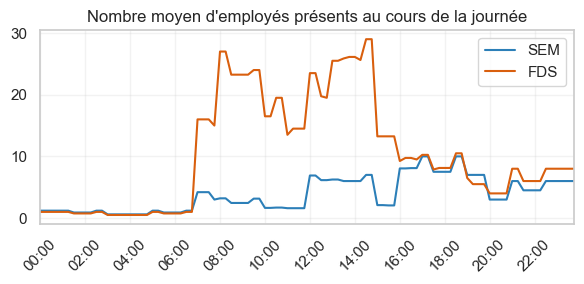

In [153]:
# Construire df_staff_per_slot directement depuis s_jh (variable s_mzn définie dans la cellule de vérification)
records = []
for j_idx, j in enumerate(J):
    is_weekend = j in JW
    for h_idx, h in enumerate(H):
        staff = (s_mzn[j_idx, h_idx])   # nombre d'employés servis à ce créneau selon MiniZinc
        records.append({
            'day': j,
            'is_weekend': is_weekend,
            'hour_slot': h,
            'num_employees': staff
        })

df_staff_per_slot = pd.DataFrame(records)
print("df_staff_per_slot (depuis s_jh):")
display(df_staff_per_slot.head())

# Moyennes semaine / weekend et tracés
weekday_curve = (
    df_staff_per_slot[~df_staff_per_slot['is_weekend']]
    .groupby('hour_slot')['num_employees']
    .mean()
)
weekend_curve = (
    df_staff_per_slot[df_staff_per_slot['is_weekend']]
    .groupby('hour_slot')['num_employees']
    .mean()
)

x_slots = list(H)
plt.figure(figsize=(6,3))
plt.plot(x_slots, weekday_curve.values, label='SEM', color="#2c7fb8")
plt.plot(x_slots, weekend_curve.values, label='FDS', color="#d95f0e")
plt.title("Nombre moyen d'employés présents au cours de la journée")
plt.xticks(ticks=range(1,97,8), labels=[slot_to_time_15(h) for h in range(1,97,8)], rotation=45)
plt.grid(alpha=0.25)
# Set xlim(1,96)
plt.xlim(1, 96)
plt.margins(x=0)
plt.legend()
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_1.pdf'),format='pdf',bbox_inches='tight')
plt.show()


## 6. Critère — Distribution du nombre de patients en attente / en appel au cours de la journée

df_patients_per_slot:


,day,hour_slot,patients,staff,is_weekend
0,1,1,3,2.0,False
1,1,2,3,2.0,False
2,1,3,2,2.0,False
3,1,4,4,2.0,False
4,1,5,2,2.0,False


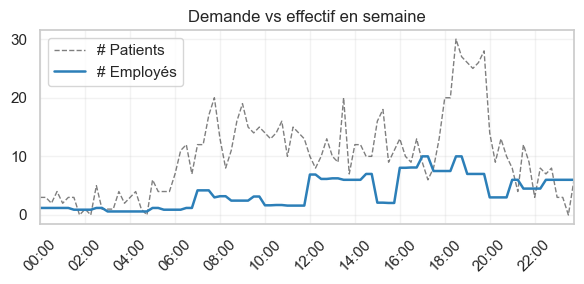

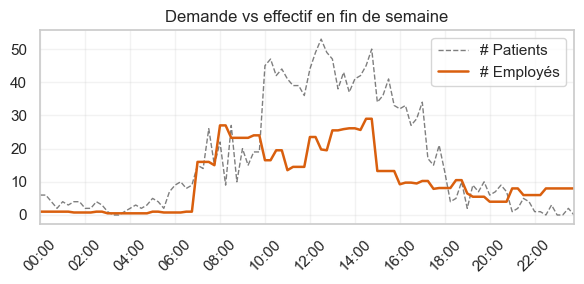

In [154]:
n_jh = data['n_jh']
lmd = data['lmd']

records = []
for j in J:
    is_weekend = j in JW
    for h_idx, h in enumerate(H):
        patients = int(np.ceil(n_jh[j-1, h_idx]/7.5))
        staff = df_staff_per_slot.query("day == @j and hour_slot == @h")['num_employees'].iloc[0]
        records.append({
            'day': j,
            'hour_slot': h,
            'patients': patients,
            'staff': staff,
            'is_weekend': is_weekend
        })

df_patients_per_slot = pd.DataFrame(records)
print("df_patients_per_slot:")
display(df_patients_per_slot.head())

# Moyennes séparées semaine / weekend (réindexer sur H pour garantir la continuité)
mean_patients_weekday = (
    df_patients_per_slot[~df_patients_per_slot['is_weekend']]
    .groupby('hour_slot')['patients']
    .mean()
).reindex(H, fill_value=0)
mean_patients_weekend = (
    df_patients_per_slot[df_patients_per_slot['is_weekend']]
    .groupby('hour_slot')['patients']
    .mean()
).reindex(H, fill_value=0)
mean_staff_weekday = (
    df_patients_per_slot[~df_patients_per_slot['is_weekend']]
    .groupby('hour_slot')['staff']
    .mean()
).reindex(H, fill_value=0)
mean_staff_weekend = (
    df_patients_per_slot[df_patients_per_slot['is_weekend']]
    .groupby('hour_slot')['staff']
    .mean()
).reindex(H, fill_value=0)

# Weekday: Patients vs Staff (separate figure) — updated x-axis style
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(H, mean_patients_weekday.values, label='# Patients', color="#000000", linestyle='--', linewidth=1, alpha=0.5)
ax.plot(H, mean_staff_weekday.values, label='# Employés', color="#2c7fb8", linestyle='-', linewidth=1.8)
ax.set_title("Demande vs effectif en semaine")
# x limits and margins
ax.set_xlim(min(H), max(H))
ax.margins(x=0)
# xticks every 2 hours -> every 8 slots (8 * 15min = 120min)
ax.set_xticks(ticks=range(1, 97, 8))
ax.set_xticklabels([slot_to_time_15(h) for h in range(1, 97, 8)], rotation=45)
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_2.pdf'),format='pdf',bbox_inches='tight')
plt.show()

# Weekend: Patients vs Staff (separate figure) — updated x-axis style
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(H, mean_patients_weekend.values, label='# Patients', color="#000000", linestyle='--', linewidth=1, alpha=0.5)
ax.plot(H, mean_staff_weekend.values, label='# Employés', color="#d95f0e", linestyle='-', linewidth=1.8)
ax.set_title("Demande vs effectif en fin de semaine")
# x limits and margins
ax.set_xlim(min(H), max(H))
ax.margins(x=0)
ax.set_xticks(ticks=range(1, 97, 8))
ax.set_xticklabels([slot_to_time_15(h) for h in range(1, 97, 8)], rotation=45)
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_3.pdf'),format='pdf',bbox_inches='tight')
plt.show()




df_service_per_slot (minutes):


,day,hour_slot,patients_min,staff_min,is_weekend
0,1,1,23,30,False
1,1,2,23,30,False
2,1,3,15,30,False
3,1,4,30,30,False
4,1,5,15,30,False


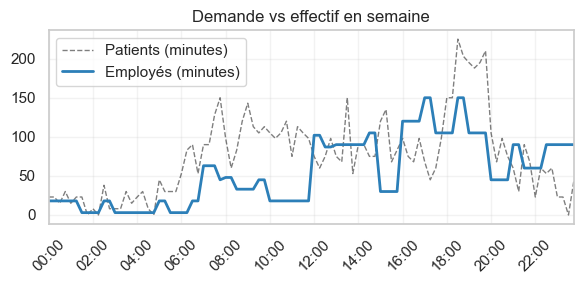

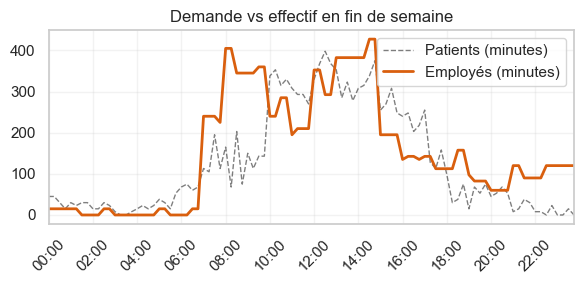

In [155]:

# --------- Nouvel ajout : "service" en minutes (patients en minutes, staff en minutes) ---------
records_min = []
for j in J:
    is_weekend = j in JW
    for h_idx, h in enumerate(H):
        # patients en minutes (pas de division par 7.5)
        patients_min = int(np.ceil(n_jh[j-1, h_idx]))
        # staff en minutes = nombre de staff * 15 (minutes par tranche)
        staff_count = df_staff_per_slot.query("day == @j and hour_slot == @h")['num_employees'].iloc[0]
        staff_min = int(staff_count) * 15
        records_min.append({
            'day': j,
            'hour_slot': h,
            'patients_min': patients_min,
            'staff_min': staff_min,
            'is_weekend': is_weekend
        })

df_service_per_slot = pd.DataFrame(records_min)
print("\ndf_service_per_slot (minutes):")
display(df_service_per_slot.head())

# Moyennes semaine / weekend (minutes)
mean_patients_min_weekday = (
    df_service_per_slot[~df_service_per_slot['is_weekend']]
    .groupby('hour_slot')['patients_min']
    .mean()
).reindex(H, fill_value=0)
mean_patients_min_weekend = (
    df_service_per_slot[df_service_per_slot['is_weekend']]
    .groupby('hour_slot')['patients_min']
    .mean()
).reindex(H, fill_value=0)
mean_staff_min_weekday = (
    df_service_per_slot[~df_service_per_slot['is_weekend']]
    .groupby('hour_slot')['staff_min']
    .mean()
).reindex(H, fill_value=0)
mean_staff_min_weekend = (
    df_service_per_slot[df_service_per_slot['is_weekend']]
    .groupby('hour_slot')['staff_min']
    .mean()
).reindex(H, fill_value=0)

# Weekday minutes (separate)
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(H, mean_patients_min_weekday.values, label='Patients (minutes)', color="#000000", linestyle='--', linewidth=1, alpha=0.5)
ax.plot(H, mean_staff_min_weekday.values, label='Employés (minutes)', color="#2c7fb8", linestyle='-', linewidth=2)
ax.set_title("Demande vs effectif en semaine")
ax.set_xticks(ticks=range(1,97,8))
ax.set_xticklabels([slot_to_time_15(h) for h in range(1,97,8)], rotation=45)
ax.legend()
ax.set_xlim(min(H), max(H))
ax.margins(x=0)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_4.pdf'),format='pdf',bbox_inches='tight')
plt.show()

# Weekend minutes (separate)
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(H, mean_patients_min_weekend.values, label='Patients (minutes)', color="#000000", linestyle='--', linewidth=1, alpha=0.5)
ax.plot(H, mean_staff_min_weekend.values, label='Employés (minutes)', color="#d95f0e", linestyle='-', linewidth=2)
ax.set_title("Demande vs effectif en fin de semaine")
ax.set_xticks(ticks=range(1,97,8))
ax.set_xticklabels([slot_to_time_15(h) for h in range(1,97,8)], rotation=45)
ax.legend()
ax.set_xlim(min(H), max(H))
ax.margins(x=0)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_5.pdf'),format='pdf',bbox_inches='tight')
plt.show()


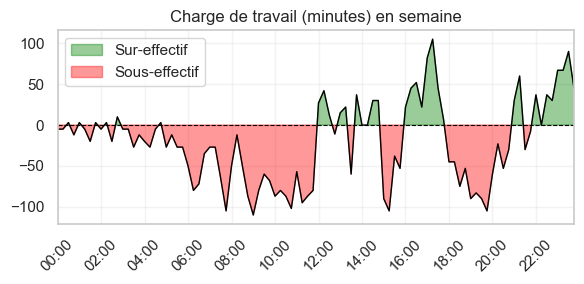

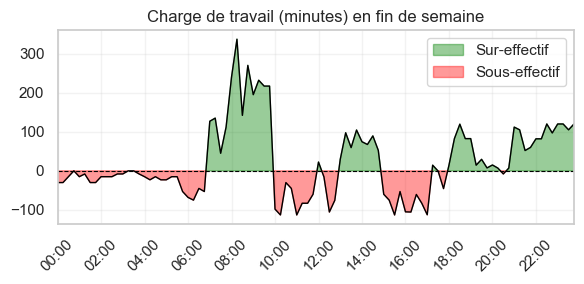

In [156]:


# Inverted curve (capacité - demande) colorisée : vert = sur-effectif, rouge = sous-effectif
inv_weekday = mean_staff_min_weekday.values - mean_patients_min_weekday.values
inv_weekend = mean_staff_min_weekend.values - mean_patients_min_weekend.values

# Semaine (separate)
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(H, inv_weekday, color='black', linewidth=1)
ax.fill_between(H, inv_weekday, 0, where=inv_weekday>0, interpolate=True, color='green', alpha=0.4, label='Sur-effectif')
ax.fill_between(H, inv_weekday, 0, where=inv_weekday<0, interpolate=True, color='red', alpha=0.4, label='Sous-effectif')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title("Charge de travail (minutes) en semaine")
# x limits and margins
ax.set_xlim(min(H), max(H))
ax.margins(x=0)
# xticks every 2 hours -> every 8 slots (8 * 15min = 120min)
ax.set_xticks(ticks=range(1, 97, 8))
ax.set_xticklabels([slot_to_time_15(h) for h in range(1, 97, 8)], rotation=45)
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_6.pdf'),format='pdf',bbox_inches='tight')
plt.show()

# Weekend (separate)
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(H, inv_weekend, color='black', linewidth=1)
ax.fill_between(H, inv_weekend, 0, where=inv_weekend>0, interpolate=True, color='green', alpha=0.4, label='Sur-effectif')
ax.fill_between(H, inv_weekend, 0, where=inv_weekend<0, interpolate=True, color='red', alpha=0.4, label='Sous-effectif')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title("Charge de travail (minutes) en fin de semaine")
# x limits and margins
ax.set_xlim(min(H), max(H))
ax.margins(x=0)
# xticks every 2 hours -> every 8 slots
ax.set_xticks(ticks=range(1, 97, 8))
ax.set_xticklabels([slot_to_time_15(h) for h in range(1, 97, 8)], rotation=45)
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_7.pdf'),format='pdf',bbox_inches='tight')
plt.show()


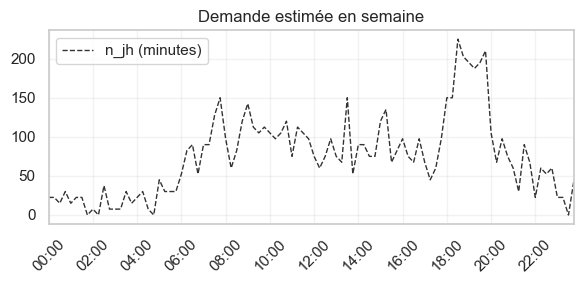

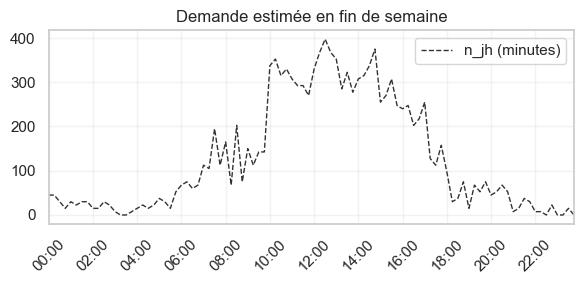

In [157]:
# mask des jours weekend
is_weekend = np.array([j in JW for j in J])

# Extraire la demande n_jh (shape: num_J x H)
demand = np.array(n_jh)  # déjà en minutes dans data['n_jh']

# Moyennes par tranche (gestion si pas de jours de type)
if np.any(~is_weekend):
    mean_weekday = demand[~is_weekend].mean(axis=0)
else:
    mean_weekday = np.zeros(len(H))

if np.any(is_weekend):
    mean_weekend = demand[is_weekend].mean(axis=0)
else:
    mean_weekend = np.zeros(len(H))

# Tracé 1 : semaine (figure séparée) — couper exactement à 00:00 / 24:00
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(H, mean_weekday, color="#000000", linestyle='--', label="n_jh (minutes)", linewidth=1, alpha=0.8)
ax.set_title("Demande estimée en semaine")
ax.legend()

# major = every 2 hours (labels), minor = every 1 hour (small ticks)
major_ticks = list(range(1, 97, 8))   # 8 * 15min = 2h
minor_ticks = list(range(1, 97, 4))   # 4 * 15min = 1h
ax.set_xticks(major_ticks)
ax.set_xticks(minor_ticks, minor=True)
ax.set_xticklabels([slot_to_time_15(h) for h in major_ticks], rotation=45)

# small/minor tick appearance
ax.tick_params(axis='x', which='major', length=6)
ax.tick_params(axis='x', which='minor', length=3)
ax.grid(alpha=0.25, which='major')
ax.set_xlim(1, 96)    # couper précisément aux bornes 00:00 / 24:00
ax.margins(x=0)       # supprimer tout padding horizontal
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_8.pdf'),format='pdf',bbox_inches='tight')
plt.show()
fig.savefig("img/visu_njh_sem.pdf", format='pdf', bbox_inches='tight')


# Tracé 2 : weekend (figure séparée) — mêmes réglages
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(H, mean_weekend, color="#000000", linestyle='--', label="n_jh (minutes)", linewidth=1, alpha=0.8)
ax.set_title("Demande estimée en fin de semaine")
ax.legend()

ax.set_xticks(major_ticks)
ax.set_xticks(minor_ticks, minor=True)
ax.set_xticklabels([slot_to_time_15(h) for h in major_ticks], rotation=45)
ax.tick_params(axis='x', which='major', length=6)
ax.tick_params(axis='x', which='minor', length=3)
ax.grid(alpha=0.25, which='major')
ax.set_xlim(1, 96)
ax.margins(x=0)
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_9.pdf'),format='pdf',bbox_inches='tight')
plt.show()
fig.savefig("img/visu_njh_fds.pdf", format='pdf', bbox_inches='tight')


## 7. Critère — Distribution de la demande insatisfaite

TODO: Tout garder en temps de service

df_hangups_z (démande insatisfaite depuis z_jh):


,day,hour_slot,minutes_unserved,hangups,staff,is_weekend
0,1,1,8,8,2.0,False
1,1,2,8,8,2.0,False
2,1,3,0,0,2.0,False
3,1,4,15,15,2.0,False
4,1,5,0,0,2.0,False


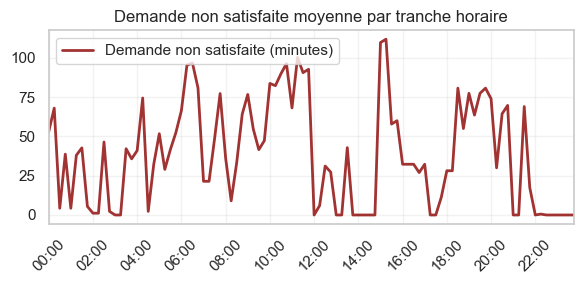

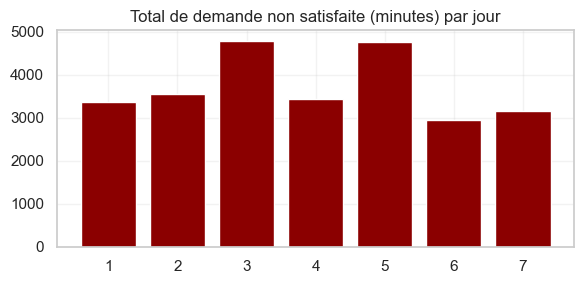

In [158]:
# Utiliser z_jh (z_mzn) fourni par la solution MiniZinc pour refaire les mêmes graphiques
records = []
for j in J:
    is_weekend = j in JW
    for h_idx, h in enumerate(H):
        minutes_unserved = int(z_mzn[j-1, h_idx])   # minutes non servies selon la solution
        hangups = int(np.ceil(minutes_unserved )) 
        staff = df_staff_per_slot.query("day == @j and hour_slot == @h")['num_employees'].iloc[0]
        records.append({
            'day': j,
            'hour_slot': h,
            'minutes_unserved': minutes_unserved,
            'hangups': hangups,
            'staff': staff,
            'is_weekend': is_weekend
        })

df_hangups_z = pd.DataFrame(records)
print("df_hangups_z (démande insatisfaite depuis z_jh):")
display(df_hangups_z.head())

# Moyenne par tranche horaire (en appels)
mean_hangups = df_hangups_z.groupby('hour_slot')['hangups'].mean().reindex(H, fill_value=0)

plt.figure(figsize=(6,3))
plt.plot(H, mean_hangups.values, label="Demande non satisfaite (minutes)", color="darkred", linewidth=2, alpha=0.8)
plt.title("Demande non satisfaite moyenne par tranche horaire")
plt.xticks(ticks=range(1,97,8), labels=[slot_to_time_15(h) for h in range(1,97,8)], rotation=45)
plt.xlim(1, 96)
plt.margins(x=0)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_10.pdf'),format='pdf',bbox_inches='tight')
plt.show()

# Total appels en attente par jour
daily_hangups = df_hangups_z.groupby('day')['hangups'].sum()
plt.figure(figsize=(6,3))
plt.bar(daily_hangups.index, daily_hangups.values, color="darkred")
plt.title("Total de demande non satisfaite (minutes) par jour")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_11.pdf'),format='pdf',bbox_inches='tight')
plt.show()

## 8. Critère — Heures travaillées, overtime, variance des heures (par type d'employé)

df_employees_metrics (heures + OT):


,employee,type,total_hours,T_max,overtime
0,1,IR,40.0,80.0,0.0
1,2,IR,40.0,80.0,0.0
2,3,IR,40.0,80.0,0.0
3,4,IR,44.0,80.0,0.0
4,5,IR,40.0,80.0,0.0


Variance des heures par type:


,type,variance_hours
0,IE,26.060286
1,IP,100.102564
2,IR,1.454545


C:\Users\sacma\AppData\Local\Temp\ipykernel_5904\4129992665.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='total_hours', data=df_employees_metrics, palette="deep")


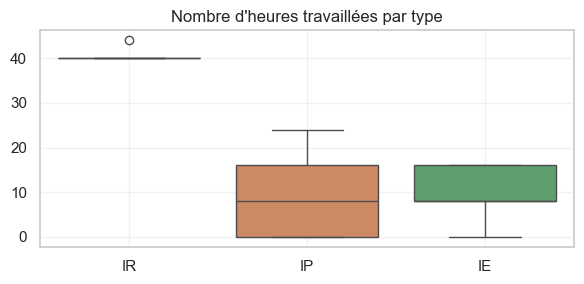

C:\Users\sacma\AppData\Local\Temp\ipykernel_5904\4129992665.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='type', y='overtime', data=df_employees_metrics, estimator=np.mean, errorbar=None, palette="deep")


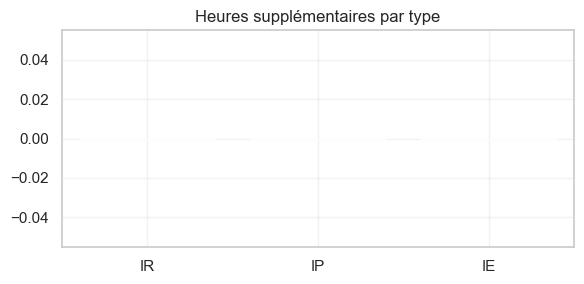

In [159]:
# Durée des quarts en heures (on divise duree_int par 2)
duree_hours = np.array([
    data['duree_int'][Q.index(q)] / 2.0
    for q in Q
])

hours_per_day = np.zeros((num_I, num_J))
for i_idx in range(num_I):
    for j_idx in range(num_J):
        hours_per_day[i_idx,j_idx] = (x_tensor[i_idx,j_idx,:] * duree_hours).sum()

total_hours = hours_per_day.sum(axis=1)
T_max = data['T_max']
overtime = np.maximum(0, total_hours - T_max)

df_employees_metrics = df_employees_info.copy()
df_employees_metrics['total_hours'] = total_hours
df_employees_metrics['T_max'] = T_max
df_employees_metrics['overtime'] = overtime

print("df_employees_metrics (heures + OT):")
display(df_employees_metrics.head())

# Variance par type
var_by_type = df_employees_metrics.groupby('type')['total_hours'].var().reset_index()
var_by_type.columns = ['type','variance_hours']
print("Variance des heures par type:")
display(var_by_type)

# Graphes
plt.figure(figsize=(6,3))
sns.boxplot(x='type', y='total_hours', data=df_employees_metrics, palette="deep")
plt.title("Nombre d'heures travaillées par type")
# dont show ax title
plt.xlabel("")
plt.ylabel("")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_12.pdf'),format='pdf',bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,3))
sns.barplot(x='type', y='overtime', data=df_employees_metrics, estimator=np.mean, errorbar=None, palette="deep")
plt.title("Heures supplémentaires par type")
plt.xlabel("")
plt.ylabel("")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_13.pdf'),format='pdf',bbox_inches='tight')
plt.show()


## 9. Critère — Nombre de jours consécutifs travaillés (par employé et par type)

Jours consécutifs par employé:


,employee,type,max_consec_days
0,1,IR,5
1,2,IR,5
2,3,IR,5
3,4,IR,5
4,5,IR,5


C:\Users\sacma\AppData\Local\Temp\ipykernel_5904\1179134152.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='max_consec_days', data=df_employees_metrics, palette="deep")


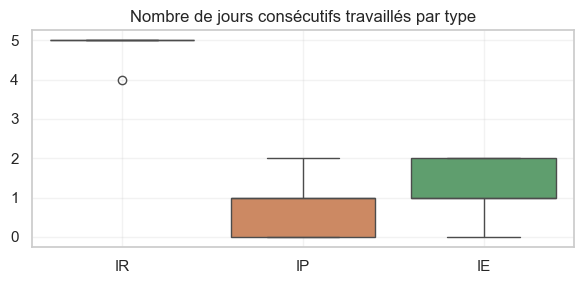

In [160]:
max_consec = np.zeros(num_I, dtype=int)
for i_idx in range(num_I):
    cur = 0
    best = 0
    for j_idx in range(num_J):
        worked = x_tensor[i_idx,j_idx,:].sum() > 0
        if worked:
            cur += 1
        else:
            best = max(best, cur)
            cur = 0
    best = max(best, cur)
    max_consec[i_idx] = best

df_employees_metrics['max_consec_days'] = max_consec

print("Jours consécutifs par employé:")
display(df_employees_metrics[['employee','type','max_consec_days']].head())

plt.figure(figsize=(6,3))
sns.boxplot(x='type', y='max_consec_days', data=df_employees_metrics, palette="deep")
plt.title("Nombre de jours consécutifs travaillés par type")
plt.xlabel("")
plt.ylabel("")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_14.pdf'),format='pdf',bbox_inches='tight')
plt.show()

## 10. Critère — Changements brusques de quarts d'un jour à l'autre

TODO : savoir  ce qu'on en fait psq c'est pas clair

Changements brusques de quart par employé:


,employee,type,abrupt_changes
0,1,IR,0
1,2,IR,1
2,3,IR,0
3,4,IR,2
4,5,IR,0


C:\Users\sacma\AppData\Local\Temp\ipykernel_5904\4083801207.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='abrupt_changes', data=df_employees_metrics, palette="deep")


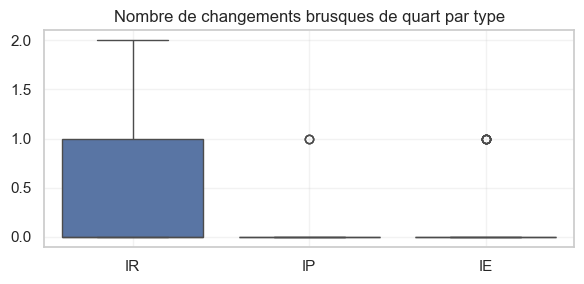

In [161]:
abrupt_changes = np.zeros(num_I, dtype=int)

for i_idx in range(num_I):
    prev_cat = None
    for j_idx in range(num_J):
        cats_present = set()
        for q_idx,q in enumerate(Q):
            if x_tensor[i_idx,j_idx,q_idx] > 0:
                if q in NIGHT:
                    cats_present.add('NIGHT')
                elif q in LONG:
                    cats_present.add('LONG')
                elif q in DAY:
                    cats_present.add('DAY')
        if 'NIGHT' in cats_present:
            cat = 'NIGHT'
        elif 'LONG' in cats_present:
            cat = 'LONG'
        elif 'DAY' in cats_present:
            cat = 'DAY'
        else:
            cat = None

        if prev_cat is not None and cat is not None and cat != prev_cat:
            abrupt_changes[i_idx] += 1
        if cat is not None:
            prev_cat = cat

df_employees_metrics['abrupt_changes'] = abrupt_changes

print("Changements brusques de quart par employé:")
display(df_employees_metrics[['employee','type','abrupt_changes']].head())

plt.figure(figsize=(6,3))
sns.boxplot(x='type', y='abrupt_changes', data=df_employees_metrics, palette="deep")
plt.title("Nombre de changements brusques de quart par type")
plt.xlabel("")
plt.ylabel("")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_15.pdf'),format='pdf',bbox_inches='tight')
plt.show()

## 11. Critère — Nuits travaillées et répartition jour / soir / nuit / long / weekend

Répartition jour/nuit/long/weekend par employé:


,employee,type,day_shifts,night_shifts,long_shifts,weekend_shifts
0,1,IR,0,5,0,0
1,2,IR,2,3,0,0
2,3,IR,5,0,0,0
3,4,IR,4,0,1,1
4,5,IR,0,5,0,0


Moyennes par type:


,Jour,Nuit,Quart de 12h,Fin de semaine
type,,,,
IR,2.636364,2.272727,0.090909,0.181818
IP,0.538462,0.769231,0.000000,0.000000
IE,0.919355,0.306452,0.000000,1.209677


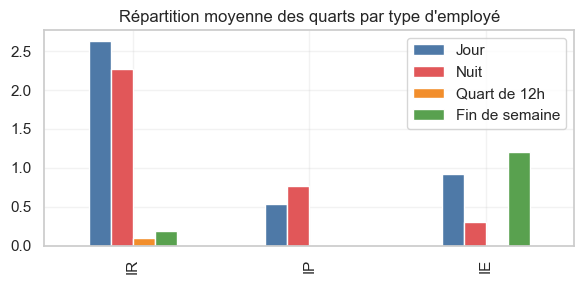

C:\Users\sacma\AppData\Local\Temp\ipykernel_5904\4222197823.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='nights', data=df_employees_metrics, palette="deep")


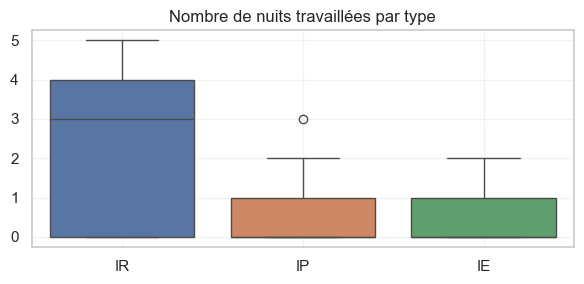

In [162]:
nights = np.zeros(num_I, dtype=int)
day_shifts = np.zeros(num_I, dtype=int)
night_shifts = np.zeros(num_I, dtype=int)
long_shifts = np.zeros(num_I, dtype=int)
weekend_shifts = np.zeros(num_I, dtype=int)

for i_idx,i in enumerate(I):
    for j_idx,j in enumerate(J):
        is_weekend = j in JW
        for q_idx,q in enumerate(Q):
            if x_tensor[i_idx,j_idx,q_idx] > 0:
                if q in DAY:
                    day_shifts[i_idx] += 1
                if q in NIGHT:
                    night_shifts[i_idx] += 1
                    nights[i_idx] += 1
                if q in LONG:
                    long_shifts[i_idx] += 1
                if is_weekend:
                    weekend_shifts[i_idx] += 1

df_employees_metrics['nights'] = nights
df_employees_metrics['day_shifts'] = day_shifts
df_employees_metrics['night_shifts'] = night_shifts
df_employees_metrics['long_shifts'] = long_shifts
df_employees_metrics['weekend_shifts'] = weekend_shifts

print("Répartition jour/nuit/long/weekend par employé:")
display(df_employees_metrics[['employee','type','day_shifts','night_shifts','long_shifts','weekend_shifts']].head())

# Graphes agrégés par type (ordre IR / IP / IE, libellés FR)
agg = df_employees_metrics.groupby('type')[['day_shifts','night_shifts','long_shifts','weekend_shifts']].mean()
agg = agg.reindex(['IR','IP','IE'])  # ordre souhaité
agg = agg.rename(columns={
    'day_shifts': 'Jour',
    'night_shifts': 'Nuit',
    'long_shifts': 'Quart de 12h',
    'weekend_shifts': 'Fin de semaine'
})
print("Moyennes par type:")
display(agg)

# Nouvelle palette de couleurs personnalisée
colors = ["#4e79a7", "#e15759", "#f28e2c", "#59a14f"]  # Jour, Nuit, Quart de 12h, Fin de semaine

ax = agg.plot(kind='bar', figsize=(6,3), color=colors)
ax.set_title("Répartition moyenne des quarts par type d'employé")
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(alpha=0.25)
ax.legend(title="")
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_16.pdf'), format='pdf', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,3))
sns.boxplot(x='type', y='nights', data=df_employees_metrics, palette="deep")
plt.title("Nombre de nuits travaillées par type")
plt.xlabel("")
plt.ylabel("")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_17.pdf'),format='pdf',bbox_inches='tight')
plt.show()

## 12. Critère — Nombre d'employés par quart et par type

df_shifts_count:


type,shift,IE,IP,IR,shift_label
0,q0_8,2,2,0,00:00-08:00
4,q7_8,27,5,4,07:00-15:00
6,q8_8,23,0,0,08:00-16:00
5,q8_12,0,0,1,08:00-20:00
1,q11_5_8,1,0,0,11:30-19:30
2,q12_8,2,0,7,12:00-20:00
3,q16_8,15,4,6,16:00-00:00


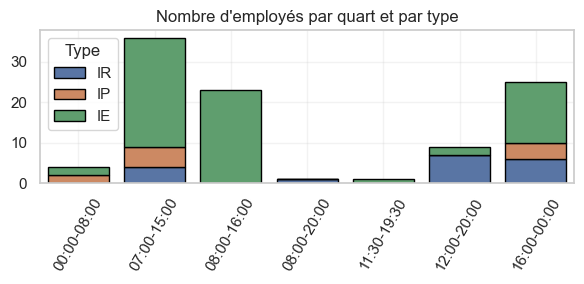

In [163]:
df_shifts_count = (
    df_schedule
    .groupby(['shift','type'])['employee']
    .nunique()
    .unstack(fill_value=0)
    .reset_index()
)

df_shifts_count['shift_label'] = df_shifts_count['shift'].map(pretty_q)
df_shifts_count = df_shifts_count.sort_values('shift_label')

print("df_shifts_count:")
display(df_shifts_count)

plt.figure(figsize=(6,3))
cols_present = [c for c in ['IR','IP','IE'] if c in df_shifts_count.columns]
palette = sns.color_palette("deep", n_colors=len(cols_present))

bottom = np.zeros(len(df_shifts_count))
for idx, col in enumerate(cols_present):
    sns.barplot(x=df_shifts_count['shift_label'], y=df_shifts_count[col], bottom=bottom, label=col, color=palette[idx], edgecolor='black')
    bottom += df_shifts_count[col].values

plt.title("Nombre d'employés par quart et par type")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=60, ha='center')
plt.legend(title="Type")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_18.pdf'),format='pdf',bbox_inches='tight')
plt.show()

## 13. Critère — Timeline horizontale des shifts par employé (Gantt)

TODO: garder le 2e en annexe

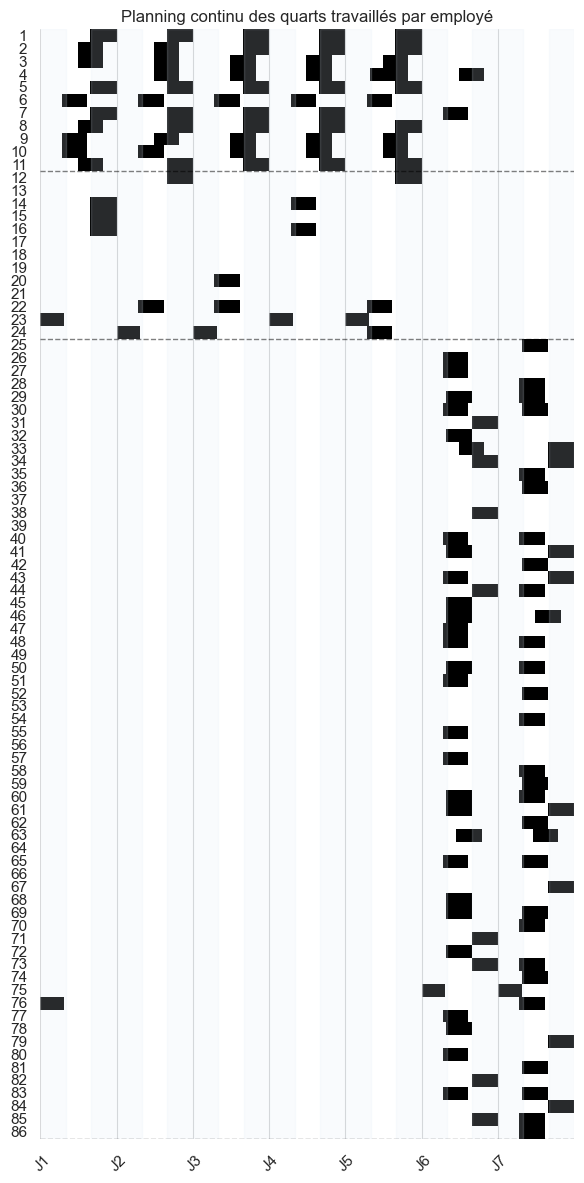

In [164]:
# Heatmap unique supprimant les 3 sous-graphes et conservant uniquement la timeline combinée (15-min slices)
num_I, num_J, num_Q = x_tensor.shape
slots_per_day = 96  # 15-min slices
total_slots = num_J * slots_per_day
a_hq = data.get('a_hq', None)  # mapping optionnel 15-min -> quart

# helper: determine if 15-min slice 'a' is inside shift q using a_hq when possible
def a_in_shift(a, q):
    if a_hq is not None:
        arr = a_hq
        try:
            return bool(arr[a + 1, q])   # 1-based a
        except Exception:
            try:
                return bool(arr[a, q])   # 0-based a
            except Exception:
                try:
                    return bool(arr[(a + 1, q)])  # dict keyed by tuple
                except Exception:
                    try:
                        return bool(arr[(a, q)])
                    except Exception:
                        pass
    # fallback to original `data` shape (support 1-based & 0-based)
    try:
        return bool(data[a + 1][q])
    except Exception:
        return bool(data[a][q])

# construire la matrice combinée (num_I x total_slots) binaire
mat_all = np.zeros((num_I, total_slots), dtype=int)
for i_idx in range(num_I):
    for j_idx in range(num_J):
        day_offset = j_idx * slots_per_day
        for q_idx in range(num_Q):
            if x_tensor[i_idx, j_idx, q_idx] > 0:
                for a in range(slots_per_day):
                    if a_in_shift(a, q_idx):
                        mat_all[i_idx, day_offset + a] = 1

# affichage unique
plt.figure(figsize=(6, 12))
ax = sns.heatmap(
    mat_all,
    cmap="Greys",
    vmin=0, vmax=1,
    cbar=False,
    yticklabels=I  # liste des employés
)
ax.set_title("Planning continu des quarts travaillés par employé")

# bandes nuit (00:00-08:00 et 16:00-24:00) et séparateurs de jours (15-min slots)
night_color = "#dfeaf7"
separator_color = "#bbbbbb"
night_blocks = [(0, int(8*4)), (int(16*4), slots_per_day)]
for d in range(num_J):
    base = d * slots_per_day
    for (s_off, e_off) in night_blocks:
        s = base + s_off
        e = base + e_off
        ax.axvspan(s, e, color=night_color, alpha=0.18, zorder=2)
    ax.axvline(base, color=separator_color, linewidth=0.6, alpha=0.6, zorder=3)

# Barre horizontale pour séparer les types d'employés
type_boundaries = {}
for t in df_employees_info['type'].unique():
    last_idx = df_employees_info[df_employees_info['type'] == t].index[-1]
    type_boundaries[t] = last_idx
for t, last_idx in type_boundaries.items():
    ax.axhline(last_idx + 1, color='black', linewidth=1, alpha=0.5, zorder=4, linestyle='--')

# xticks : début de chaque jour
day_starts = np.arange(0, total_slots, slots_per_day)
day_labels = [f"J{d}" for d in data["J"]]
ax.set_xticks(day_starts + 2)
ax.set_xticklabels(day_labels, rotation=45)

plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir, 'fig_19.pdf'), format='pdf', bbox_inches='tight')
plt.show()


📊 Impact des composantes de l'objectif :


,Terme,Valeur brute,Poids,Contribution absolue,Contribution (%)
0,Préférences,2733,1,2733,5.57
1,Couverture,-113,200,-22600,46.04
2,Heures prestées,-1188,20,-23760,48.40


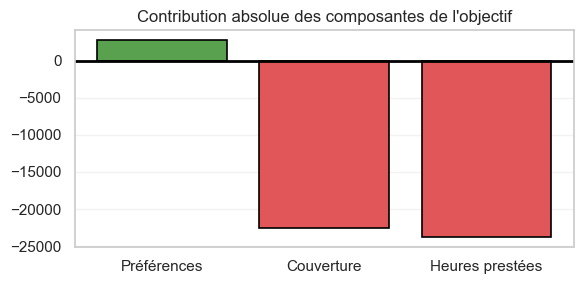

In [165]:
# =========================================================
# ANALYSE : CONTRIBUTION DES POIDS DANS L’OBJECTIF
# =========================================================

# 1) Vérification
for key in [
    "score_preferences",
    "penalite_couverture",
    "penalite_heures_tot",
]:
    if key not in sol_meta:
        raise ValueError(f"⚠️ Terme manquant dans sol_meta : {key}")

for key in [
    "w_preferences",
    "w_couverture",
    "w_heures_tot",
]:
    if key not in data:
        raise ValueError(f"⚠️ Poids manquant dans data : {key}")


# 2) Extraction des valeurs et poids
terms = {
    "Préférences": sol_meta["score_preferences"],
    "Couverture": sol_meta["penalite_couverture"],
    "Heures prestées": sol_meta["penalite_heures_tot"],
}

weights = {
    "Préférences": data["w_preferences"],
    "Couverture": data["w_couverture"],
    "Heures prestées": data["w_heures_tot"],
}

contrib = {k: terms[k] * weights[k] for k in terms}


# 3) Pourcentages (avec valeurs absolues)
total_abs = sum(abs(v) for v in contrib.values())
percent = {k: 100 * abs(contrib[k]) / total_abs for k in contrib}


# 4) Dataframe récapitulatif
df_contrib = pd.DataFrame({
    "Terme": list(terms.keys()),
    "Valeur brute": list(terms.values()),
    "Poids": list(weights.values()),
    "Contribution absolue": list(contrib.values()),
    "Contribution (%)": [round(percent[k], 2) for k in percent],
})

print("📊 Impact des composantes de l'objectif :")
display(df_contrib)

# =========================================================
# GRAPHIQUE 1 : CONTRIBUTIONS ABSOLUES (verticales)
# + grosse ligne horizontale à zéro
# =========================================================

plt.figure(figsize=(6, 3))

# Barres verticales
# color green if positive else red
colors = ["#59a14f" if v >= 0 else "#e15759" for v in df_contrib["Contribution absolue"]]
plt.bar(
    df_contrib["Terme"],
    df_contrib["Contribution absolue"],
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

# ➤ Grosse ligne à 0
plt.axhline(0, color="black", linewidth=2)

plt.title("Contribution absolue des composantes de l'objectif")


# Grille fine sur l’axe Y
plt.grid(alpha=0.25)
# pas de grille axe x
plt.gca().xaxis.grid(False)

plt.tight_layout()
plt.gcf().savefig(os.path.join(scenario_dir,'fig_20.pdf'),format='pdf',bbox_inches='tight')
plt.show()


## Export to .csv pour les autres groupes

In [166]:
my_s_jh = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 6.0, 6.0, 6.0, 5.0, 8.0, 8.0, 6.75, 6.75, 6.75, 6.75, 7.25, 7.25, 4.75, 4.75, 5.5, 5.5, 4.0, 4.0, 4.0, 4.0, 8.5, 8.5, 7.25, 7.25, 8.75, 8.75, 8.75, 8.75, 8.75, 8.75, 10.0, 10.0, 4.0, 4.0, 3.25, 3.25, 11.25, 11.25, 12.0, 12.0, 13.0, 13.0, 9.75, 9.75, 9.75, 9.75, 13.0, 13.0, 9.0, 9.0, 9.0, 9.0, 7.0, 4.0, 4.0, 4.0, 8.0, 8.0, 6.0, 6.0, 6.0, 6.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 6.0, 6.0, 6.0, 5.0, 7.0, 7.0, 5.75, 5.75, 5.75, 5.75, 6.5, 6.5, 4.0, 4.0, 4.5, 4.5, 3.5, 3.5, 3.5, 3.5, 10.0, 10.0, 8.75, 8.75, 9.75, 9.75, 9.5, 9.5, 9.5, 9.5, 11.0, 11.0, 4.0, 4.0, 3.5, 3.5, 9.5, 9.5, 10.0, 10.0, 12.0, 12.0, 9.0, 9.0, 9.0, 9.0, 12.0, 12.0, 9.0, 9.0, 9.0, 9.0, 5.0, 3.0, 3.0, 3.0, 6.0, 6.0, 4.5, 4.5, 4.5, 4.5, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 6.0, 6.0, 6.0, 5.0, 7.0, 7.0, 5.75, 5.75, 5.75, 5.75, 6.5, 6.5, 4.0, 4.0, 4.5, 4.5, 3.5, 3.5, 3.5, 3.5, 10.0, 10.0, 8.75, 8.75, 9.75, 9.75, 9.5, 9.5, 9.5, 9.5, 11.0, 11.0, 4.0, 4.0, 3.5, 3.5, 9.5, 9.5, 10.0, 10.0, 12.0, 12.0, 9.0, 9.0, 9.0, 9.0, 12.0, 12.0, 9.0, 9.0, 9.0, 9.0, 5.0, 3.0, 3.0, 3.0, 6.0, 6.0, 4.5, 4.5, 4.5, 4.5, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 6.0, 6.0, 6.0, 5.0, 8.0, 8.0, 6.75, 6.75, 6.75, 6.75, 7.25, 7.25, 4.75, 4.75, 5.5, 5.5, 4.0, 4.0, 4.0, 4.0, 8.5, 8.5, 7.25, 7.25, 8.75, 8.75, 8.75, 8.75, 8.75, 8.75, 10.0, 10.0, 4.0, 4.0, 3.25, 3.25, 11.25, 11.25, 12.0, 12.0, 13.0, 13.0, 9.75, 9.75, 9.75, 9.75, 13.0, 13.0, 9.0, 9.0, 9.0, 9.0, 7.0, 4.0, 4.0, 4.0, 8.0, 8.0, 6.0, 6.0, 6.0, 6.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 6.0, 6.0, 6.0, 5.0, 7.0, 7.0, 5.75, 5.75, 5.75, 5.75, 6.5, 6.5, 4.0, 4.0, 4.5, 4.5, 3.5, 3.5, 3.5, 3.5, 10.0, 10.0, 8.75, 8.75, 9.75, 9.75, 9.5, 9.5, 9.5, 9.5, 11.0, 11.0, 4.0, 4.0, 3.5, 3.5, 9.5, 9.5, 10.0, 10.0, 12.0, 12.0, 9.0, 9.0, 9.0, 9.0, 12.0, 12.0, 9.0, 9.0, 9.0, 9.0, 5.0, 3.0, 3.0, 3.0, 6.0, 6.0, 4.5, 4.5, 4.5, 4.5, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 13.0, 13.0, 13.0, 12.0, 31.0, 31.0, 28.0, 28.0, 28.0, 28.0, 26.25, 26.25, 20.25, 20.25, 25.0, 25.0, 15.5, 18.5, 18.5, 18.5, 24.5, 24.5, 21.5, 20.75, 30.25, 30.25, 28.5, 29.25, 29.25, 27.75, 32.5, 32.5, 20.5, 20.5, 17.25, 17.25, 11.25, 12.75, 16.0, 15.25, 15.25, 15.25, 12.0, 12.75, 12.75, 12.75, 16.0, 16.0, 16.0, 13.0, 13.0, 13.0, 13.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 13.0, 13.0, 13.0, 12.0, 31.0, 31.0, 28.0, 28.0, 28.0, 28.0, 26.25, 26.25, 20.25, 20.25, 25.0, 25.0, 15.5, 18.5, 18.5, 18.5, 24.5, 24.5, 21.5, 20.75, 30.25, 30.25, 28.5, 29.25, 29.25, 27.75, 32.5, 32.5, 20.5, 20.5, 17.25, 17.25, 11.25, 12.75, 16.0, 15.25, 15.25, 15.25, 12.0, 12.75, 12.75, 12.75, 16.0, 16.0, 16.0, 13.0, 13.0, 13.0, 13.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
s_jh = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 6.0, 6.0, 6.0, 5.0, 7.0, 7.0, 5.75, 5.75, 5.75, 5.75, 6.5, 6.5, 4.0, 4.0, 4.5, 4.5, 3.5, 3.5, 3.5, 3.5, 10.0, 10.0, 8.75, 8.75, 9.75, 9.75, 9.5, 9.5, 9.5, 9.5, 11.0, 11.0, 4.0, 4.0, 3.5, 3.5, 9.5, 9.5, 10.0, 10.0, 12.0, 12.0, 9.0, 9.0, 9.0, 9.0, 12.0, 12.0, 9.0, 9.0, 9.0, 9.0, 5.0, 3.0, 3.0, 3.0, 6.0, 6.0, 4.5, 4.5, 4.5, 4.5, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 6.0, 6.0, 6.0, 5.0, 7.0, 7.0, 5.75, 5.75, 5.75, 5.75, 6.5, 6.5, 4.0, 4.0, 4.5, 4.5, 3.5, 3.5, 3.5, 3.5, 10.0, 10.0, 8.75, 8.75, 9.75, 9.75, 9.5, 9.5, 9.5, 9.5, 11.0, 11.0, 4.0, 4.0, 3.5, 3.5, 9.5, 9.5, 10.0, 10.0, 12.0, 12.0, 9.0, 9.0, 9.0, 9.0, 12.0, 12.0, 9.0, 9.0, 9.0, 9.0, 5.0, 3.0, 3.0, 3.0, 6.0, 6.0, 4.5, 4.5, 4.5, 4.5, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 6.0, 6.0, 6.0, 5.0, 7.0, 7.0, 5.75, 5.75, 5.75, 5.75, 6.5, 6.5, 4.0, 4.0, 4.5, 4.5, 3.5, 3.5, 3.5, 3.5, 10.0, 10.0, 8.75, 8.75, 9.75, 9.75, 9.5, 9.5, 9.5, 9.5, 11.0, 11.0, 4.0, 4.0, 3.5, 3.5, 9.5, 9.5, 10.0, 10.0, 12.0, 12.0, 9.0, 9.0, 9.0, 9.0, 12.0, 12.0, 9.0, 9.0, 9.0, 9.0, 5.0, 3.0, 3.0, 3.0, 6.0, 6.0, 4.5, 4.5, 4.5, 4.5, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 6.0, 6.0, 6.0, 5.0, 8.0, 8.0, 6.75, 6.75, 6.75, 6.75, 7.25, 7.25, 4.75, 4.75, 5.5, 5.5, 4.0, 4.0, 4.0, 4.0, 8.5, 8.5, 7.25, 7.25, 8.75, 8.75, 8.75, 8.75, 8.75, 8.75, 10.0, 10.0, 4.0, 4.0, 3.25, 3.25, 11.25, 11.25, 12.0, 12.0, 13.0, 13.0, 9.75, 9.75, 9.75, 9.75, 13.0, 13.0, 9.0, 9.0, 9.0, 9.0, 7.0, 4.0, 4.0, 4.0, 8.0, 8.0, 6.0, 6.0, 6.0, 6.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 6.0, 6.0, 6.0, 5.0, 8.0, 8.0, 6.75, 6.75, 6.75, 6.75, 7.25, 7.25, 4.75, 4.75, 5.5, 5.5, 4.0, 4.0, 4.0, 4.0, 8.5, 8.5, 7.25, 7.25, 8.75, 8.75, 8.75, 8.75, 8.75, 8.75, 10.0, 10.0, 4.0, 4.0, 3.25, 3.25, 11.25, 11.25, 12.0, 12.0, 13.0, 13.0, 9.75, 9.75, 9.75, 9.75, 13.0, 13.0, 9.0, 9.0, 9.0, 9.0, 7.0, 4.0, 4.0, 4.0, 8.0, 8.0, 6.0, 6.0, 6.0, 6.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 13.00000000000002, 13.00000000000002, 13.00000000000002, 12.00000000000002, 31.00000000000002, 31.00000000000002, 28.00000000000002, 28.00000000000002, 28.00000000000002, 28.00000000000002, 26.25000000000002, 26.25000000000002, 20.25000000000001, 20.25000000000001, 25.00000000000001, 25.00000000000001, 15.50000000000001, 18.50000000000001, 18.50000000000001, 18.50000000000001, 24.50000000000002, 24.50000000000002, 21.50000000000002, 20.75000000000002, 30.25000000000002, 30.25000000000002, 28.50000000000002, 29.25000000000002, 29.25000000000002, 27.75000000000002, 32.50000000000003, 32.50000000000003, 20.5, 20.5, 17.25, 17.25, 11.25, 12.75, 16.0, 15.25, 15.25, 15.25, 12.0, 12.75, 12.75, 12.75, 16.0, 16.0, 16.0, 13.0, 13.0, 13.0, 13.0, 0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.75, 0.75, 1.0, 1.0, 14.0, 14.0, 14.0, 13.0, 31.0, 31.0, 27.75, 27.75, 27.75, 27.75, 26.5, 26.5, 20.0, 20.0, 24.5, 24.5, 15.5, 18.5, 18.5, 18.5, 25.0, 25.0, 21.75, 21.0, 30.0, 30.0, 28.75, 29.5, 29.5, 28.0, 32.5, 32.5, 19.5, 19.5, 16.25, 16.25, 11.25, 12.75, 16.0, 15.25, 15.25, 15.25, 12.0, 12.75, 12.75, 12.75, 16.0, 16.0, 16.0, 13.0, 13.0, 13.0, 13.0, 0.0, 0.0, 0.0, -0.0, -0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

#s_jh = data["s_jh"]
best_s = np.ceil(s_jh)
# save best_s as txt file
np.savetxt("best_s.txt", best_s, fmt="%d")

In [167]:
# Create csv file with columns : "jour", "heure_debut", "timestamp_debut", "nb_employes"
with open("sol_antoine_sacha.csv", "w") as f:
    f.write("jour,heure_debut,timestamp_debut,nb_employes\n")
    for i in range(len(best_s)):
        jour = i // 96 + 1
        # heure_debut en heures (0.25 = 15 minutes) — use modulo 96 pour garder l'heure du jour
        heure_debut = (i % 96) * 0.25
        # convertir en minutes pour éviter les problèmes d'arrondi
        total_minutes = int(round(heure_debut * 60))
        hh = (total_minutes // 60) % 24
        mm = total_minutes % 60
        timestamp_debut = f"{hh:02d}:{mm:02d}"
        nb_employes = int(best_s[i])
        f.write(f"{jour},{heure_debut},{timestamp_debut},{nb_employes}\n")